In [111]:

import pandas as pd
import json
import numpy as np

#############################################################################################################################
#############################################################################################################################
#############################################################################################################################
# 打开单个文件
epi_ind = 150
time_ind = 0
df = pd.read_parquet(f"/home/YY/Datasets/GR00T/FZWX_0423_train_FOAM/data/chunk-000/episode_{epi_ind:06d}.parquet")
# df = pd.read_parquet(f"/home/YY/Datasets/GR00T/so100_twin_cam_duck_v5/data/chunk-000/episode_00000{epi_ind}.parquet")
# df = pd.read_parquet("/home/Isaac-GR00T/demo_data/robot_sim.PickNPlace/data/chunk-000/episode_000000.parquet")
df

,observation.state,action,episode_index,frame_index,index,task_index,timestamp
0,"[-0.0024795532, -0.002861023, -0.0036239624, 0...","[-0.0024795532, -0.002861023, -0.0036239624, 0...",150,0,99800,0,0.000000
1,"[-0.0024795532, -0.002861023, -0.0036239624, 0...","[-0.002861023, -0.002861023, -0.0036239624, 0....",150,1,99801,0,0.033333
2,"[-0.0024795532, -0.002861023, -0.0036239624, 0...","[-0.0024795532, -0.002861023, -0.0036239624, 0...",150,2,99802,0,0.066667
3,"[-0.0024795532, -0.002861023, -0.0036239624, 0...","[-0.002861023, -0.002861023, -0.0036239624, 0....",150,3,99803,0,0.100000
4,"[-0.0024795532, -0.002861023, -0.0036239624, 0...","[-0.002861023, -0.002861023, -0.0036239624, 0....",150,4,99804,0,0.133333
...,...,...,...,...,...,...,...
795,"[-0.26340866, 0.06580448, 0.087548256, -0.2512...","[-0.26340866, 0.06580448, 0.087548256, -0.2512...",150,795,100595,0,26.500002
796,"[-0.2630272, 0.06580448, 0.087548256, -0.25120...","[-0.26340866, 0.06580448, 0.087548256, -0.2512...",150,796,100596,0,26.533335
797,"[-0.26340866, 0.06580448, 0.087548256, -0.2512...","[-0.26340866, 0.06580448, 0.087548256, -0.2512...",150,797,100597,0,26.566668
798,"[-0.26340866, 0.06580448, 0.087929726, -0.2512...","[-0.26340866, 0.06580448, 0.087548256, -0.2512...",150,798,100598,0,26.600002


In [112]:

print('='*100)
print(len(df['observation.state'][0]), df['observation.state'][0].shape, df['action'][0].dtype)
print(df['timestamp'][0].dtype)
print(df.head())
print(df.shape)
# print(len(df.iloc[0]['action']))

# df = pd.read_parquet("your_file.parquet")



8 (8,) float32
float32
                                   observation.state  \
0  [-0.0024795532, -0.002861023, -0.0036239624, 0...   
1  [-0.0024795532, -0.002861023, -0.0036239624, 0...   
2  [-0.0024795532, -0.002861023, -0.0036239624, 0...   
3  [-0.0024795532, -0.002861023, -0.0036239624, 0...   
4  [-0.0024795532, -0.002861023, -0.0036239624, 0...   

                                              action  episode_index  \
0  [-0.0024795532, -0.002861023, -0.0036239624, 0...            150   
1  [-0.002861023, -0.002861023, -0.0036239624, 0....            150   
2  [-0.0024795532, -0.002861023, -0.0036239624, 0...            150   
3  [-0.002861023, -0.002861023, -0.0036239624, 0....            150   
4  [-0.002861023, -0.002861023, -0.0036239624, 0....            150   

   frame_index  index  task_index  timestamp  
0            0  99800           0   0.000000  
1            1  99801           0   0.033333  
2            2  99802           0   0.066667  
3            3  99803    

In [113]:

#############################################################################################################################
#############################################################################################################################
#############################################################################################################################
print('='*100)
# 取出第一行并转换为字典
first_row = df.iloc[time_ind].to_dict()

lines = ["{"]
for i, (key, value) in enumerate(first_row.items()):
    # 如果 value 是 ndarray 类型，则转换为列表
    if isinstance(value, np.ndarray):
        value = value.tolist()
    # 将 key 和 value 转换为 JSON 格式的字符串
    line = f'    {json.dumps(key)}: {json.dumps(value)}'
    if i < len(first_row) - 1:
        line += ","
    lines.append(line)
lines.append("}")

formatted_json = "\n".join(lines)
print(formatted_json)


{
    "observation.state": [-0.00247955322265625, -0.00286102294921875, -0.00362396240234375, 0.00591278076171875, -0.00133514404296875, -0.00133514404296875, -0.00057220458984375, 4.67173957824707],
    "action": [-0.00247955322265625, -0.00286102294921875, -0.00362396240234375, 0.00591278076171875, -0.00019073486328125, -0.00133514404296875, -0.00095367431640625, 4.669832229614258],
    "episode_index": 150,
    "frame_index": 0,
    "index": 99800,
    "task_index": 0,
    "timestamp": 0.0
}


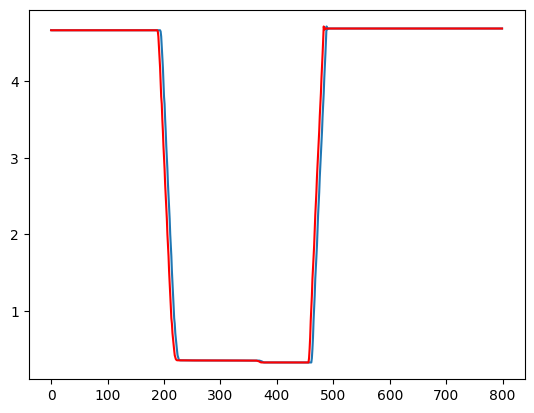

In [114]:
# plot joints state+action across time step
import matplotlib.pyplot as plt

joint_num = 7

all_time_joint_state = [df['observation.state'][j][joint_num] for j in range(df.shape[0])]
all_time_joint_action = [df['action'][j][joint_num] for j in range(df.shape[0])]
plt.plot(all_time_joint_state)
plt.plot(all_time_joint_action, color = 'red')

In [108]:
df['observation.state'][100]


array([ 0.22068405, -0.02765656,  0.05703068,  0.3164339 , -0.06847477,
       -0.03643131,  0.18482494,  4.669832  ], dtype=float32)

In [109]:
df['action'][100]


array([ 0.22068405, -0.02765656,  0.05703068,  0.3164339 , -0.06847477,
       -0.03643131,  0.18482494,  4.669832  ], dtype=float32)

## Analysis JSON generated by real remote robot

In [64]:
import os
import json
import pandas as pd
from glob import glob
import numpy as np

# 指定JSON文件所在的目录
data_dir = '/nasPublic/YY/datasets/GR00T/remote_data'

# 使用glob寻找所有匹配的JSON文件
json_files = glob(os.path.join(data_dir, 'observation_*.json'))

# 创建一个列表来存储数据
data = []

# 遍历所有JSON文件
for json_file in json_files:
    # 从文件名提取时间戳信息
    filename = os.path.basename(json_file)
    timestamp = filename.split('_')[1] + '_' + filename.split('_')[2].split('.')[0]
    
    # 打开并读取JSON文件
    with open(json_file, 'r') as f:
        json_data = json.load(f)
    
    # 提取所需的键值
    right_arm = json_data.get('state.right_arm', [])
    right_gripper = json_data.get('state.right_gripper', [])
    
    # 将提取的数据添加到列表中
    data.append({
        'timestamp': timestamp,
        'state.right_arm': right_arm,
        'state.right_gripper': right_gripper[0] if right_gripper else None
    })

# 将列表转换为DataFrame
df_remote = pd.DataFrame(data)

# 按照时间戳排序
df_remote.sort_values('timestamp', inplace=True)

# 删除时间戳列，仅保留所需的两列
df_remote = df_remote[['state.right_arm', 'state.right_gripper']].reset_index(drop=True)

# 显示DataFrame的基本信息
print(f"DataFrame shape: {df_remote.shape}")
print(df_remote.head())

# 如果需要保存DataFrame，可以取消下面的注释
# final_df.to_pickle('arm_gripper_data.pkl')  # 保存为pickle文件以保留数组结构
# final_df.to_csv('arm_gripper_data.csv')     # 保存为CSV (注意:数组会被转换为字符串)

DataFrame shape: (620, 2)
                                     state.right_arm  state.right_gripper
0  [5.216487884521484, -0.00286102294921875, -0.0...            -0.016975
1  [4.575227737426758, 0.22259140014648438, -0.04...            -0.012016
2  [4.666017532348633, 0.14400672912597656, -0.03...            -0.012398
3  [4.66563606262207, 0.10395240783691406, -0.032...            -0.011253
4  [4.66563606262207, 0.10891151428222656, -0.032...            -0.007057


In [65]:
df_remote.iloc[-1]

state.right_arm        [4.347105026245117, 0.3713665008544922, -0.029...
state.right_gripper                                            -0.020027
Name: 619, dtype: object

joint_num: 10


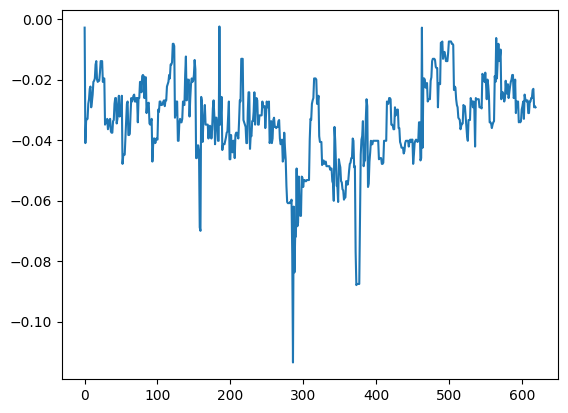

In [66]:
# plot joints state+action across time step
import matplotlib.pyplot as plt

if joint_num != 15:
    print(f"joint_num: {joint_num}")
    all_real_joint_state = [df_remote['state.right_arm'][j][joint_num-8] for j in range(df_remote.shape[0])]
else:
    print(f"joint_num: {joint_num}")
    all_real_joint_state = [df_remote['state.right_gripper'][j] for j in range(df_remote.shape[0])]
plt.plot(all_real_joint_state)

# 修改chunk里的parquet的action和state错开：


In [110]:

import os
import pandas as pd

# 输入和输出目录路径
input_dir = '/home/YY/Datasets/GR00T/FZWX_0423_train_FOAM/data/origin-000'
output_dir = '/home/YY/Datasets/GR00T/FZWX_0423_train_FOAM/data/chunk-000'

# 确保输出目录存在
os.makedirs(output_dir, exist_ok=True)

# 遍历输入目录中的所有 Parquet 文件
for filename in os.listdir(input_dir):
    if filename.endswith('.parquet'):
        # 构建文件路径
        input_path = os.path.join(input_dir, filename)
        output_path = os.path.join(output_dir, filename)
        
        # 读取 Parquet 文件
        df = pd.read_parquet(input_path)
        
        # 将 'state' 列错开一行赋值给 'action' 列
        df['action'] = df['observation.state'].shift(-5)
        df['action'] = df['action'].fillna(method='ffill')
        
        # 将处理后的 DataFrame 保存为新的 Parquet 文件
        df.to_parquet(output_path)


/tmp/ipykernel_1988223/2527283887.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['action'] = df['action'].fillna(method='ffill')
/tmp/ipykernel_1988223/2527283887.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['action'] = df['action'].fillna(method='ffill')
/tmp/ipykernel_1988223/2527283887.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['action'] = df['action'].fillna(method='ffill')
/tmp/ipykernel_1988223/2527283887.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['action'] = df['action'].fillna(method='ffill')
/tmp/ipykernel_1988223/2527283887.py:23: FutureWarning: Series.fillna with 'method' is depre

<center><h1>Appendix</h1></center>

In [ ]:

#############################################################################################################################
#############################################################################################################################
#############################################################################################################################
# 查看视频里的frame数量
# import cv2

# # # 替换为您的MP4视频文件路径
# video_path = f'/home/Isaac-GR00T/demo_data/so100_strawberry_grape/videos/chunk-000/observation.images.webcam/episode_0000{epi_ind}.mp4'

# def get_video_frames_opencv(video_path):
#     """
#     使用OpenCV获取视频帧数
#     """
#     video = cv2.VideoCapture(video_path)
#     frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
#     video.release()
#     return frame_count
# print(f"OpenCV方法帧数: {get_video_frames_opencv(video_path)}")
